# pyFragility: MLE vs. sandwich (QMLE) uncertainty in collapse fragility

Example implementation for Dahal, Burton & Onyambu (2022), *Quantifying the effect of probability model
misspecification in seismic collapse risk assessment*, Structural Safety 96, 102185.

Collapse data are multiple-stripe-analysis (MSA) results for eight wood-frame buildings: 45 ground motions at each of
16 intensity levels.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

import pyFragility as pf
from pyFragility.variance import covariance_estimates  # reference implementation, for Appendix B

## Load the data

In [2]:
df = pd.read_csv("data/MSACollapseCountData.csv", encoding="utf-8-sig")
hazard_level = df.pop("Intensity Measure").to_numpy()
num_gm = 45 * np.ones(len(hazard_level))
return_period = [15, 25, 50, 75, 100, 150, 250, 500, 1000, 2500, 2700, 3000, 3300, 3500, 3700, 4000]

hazard = pf.HazardCurve.from_return_periods(hazard_level, return_period)

## Fit all buildings

For each building: the MLE of the median (θ) and log-standard deviation (β); their variances under correct
specification (inverse Fisher information, "MLE") and under misspecification (Huber-White sandwich, "QMLE");
and the mean annual frequency of collapse (MAFC) with its uncertainty.

In [3]:
rows = []
for name in df.columns:
    counts = df[name].to_numpy()
    fit = pf.fit_msa(hazard_level, counts, num_gm)  # lognormal (theta, beta)
    glm = pf.fit_msa(hazard_level, counts, num_gm, parametrization="glm")  # probit GLM on ln(IM)
    mle_cov, sandwich_cov = fit.covariance("mle"), fit.covariance("sandwich")
    theta, beta = fit.params
    mafc = pf.mean_annual_frequency(fit, hazard)
    rows.append(
        {
            "Building Name": name,
            r"Median($\theta$)": theta,
            r"log-std($\beta$)": beta,
            r"Var[$\theta$]": mle_cov[0, 0],
            r"Var[$\beta$]": mle_cov[1, 1],
            r"QVar[$\theta$]": sandwich_cov[0, 0],
            r"QVar[$\beta$]": sandwich_cov[1, 1],
            r"CoV_$\theta$": np.sqrt(mle_cov[0, 0]) / theta,
            r"CoV_$\beta$": np.sqrt(mle_cov[1, 1]) / beta,
            r"QCoV_$\theta$": np.sqrt(sandwich_cov[0, 0]) / theta,
            r"QCoV_$\beta$": np.sqrt(sandwich_cov[1, 1]) / beta,
            r"MAFC($\lambda_c$)": mafc,
            # uncertainty of the MAFC (paper Eq. 12) from R's glm covariance ("MLE") and the sandwich
            r"MLEStd[$\lambda_c$]": pf.frequency_uncertainty(
                glm, hazard, cov="expected", method="paper"
            ).std,
            r"QMLEStd[$\lambda_c$]": pf.frequency_uncertainty(
                glm, hazard, cov="sandwich", method="paper"
            ).std,
            "50yr_ProbCollapse": float(pf.probability_in_period(mafc, 50)),
            "Var(lambdaCSimulated)": pf.frequency_uncertainty(
                glm, hazard, cov="expected", num_samples=500, seed=42
            ).std
            ** 2,
        }
    )

results = pd.DataFrame(rows)
results

,Building Name,Median($\theta$),log-std($\beta$),Var[$\theta$],Var[$\beta$],QVar[$\theta$],QVar[$\beta$],CoV_$\theta$,CoV_$\beta$,QCoV_$\theta$,QCoV_$\beta$,MAFC($\lambda_c$),MLEStd[$\lambda_c$],QMLEStd[$\lambda_c$],50yr_ProbCollapse,Var(lambdaCSimulated)
0,B1-Existing,1.219447,0.310066,0.001268,0.000645,0.000601,0.000365,0.029205,0.081907,0.020102,0.061623,0.002743,0.000281,0.000189,0.128150,5.080160e-08
1,B1-Retrofit,3.145133,0.303292,0.006406,0.000681,0.001015,0.000145,0.025448,0.086065,0.010130,0.039727,0.000150,0.000017,0.000007,0.007483,2.025202e-10
2,B2-Existing,2.381143,0.571751,0.008149,0.001565,0.004209,0.000791,0.037911,0.069202,0.027247,0.049206,0.000918,0.000166,0.000123,0.044841,2.541029e-08
3,B2-Retrofit,4.446184,0.399264,0.030246,0.002418,0.004862,0.001040,0.039115,0.123153,0.015683,0.080774,0.000081,0.000013,0.000009,0.004027,1.070072e-10
4,B3-Existing,0.812512,0.398066,0.000705,0.001059,0.000427,0.000307,0.032673,0.081756,0.025440,0.043987,0.007955,0.000715,0.000510,0.328171,3.176901e-07
5,B3-Retrofit,2.730468,0.517421,0.009539,0.001502,0.003794,0.000483,0.035770,0.074897,0.022559,0.042462,0.000506,0.000099,0.000068,0.024988,9.119104e-09
6,B4-Existing,1.407066,0.532822,0.002746,0.001107,0.000684,0.000360,0.037244,0.062456,0.018584,0.035633,0.003052,0.000384,0.000232,0.141508,1.167762e-07
7,B4-Retoifit,2.671181,0.490574,0.008491,0.001333,0.004029,0.000654,0.034496,0.074433,0.023763,0.052125,0.000483,0.000092,0.000077,0.023857,7.743045e-09


## Parameter distributions: existing vs. retrofitted

Asymptotic normal distributions of θ and β. `buildingNo` selects the archetype (1, 3, 5, 7 are the existing
buildings B1-B4; the retrofitted building follows immediately after).

In [4]:
def parameter_pdf(ax, mean, var, color, label=None, linestyle="-", seed=None, hist_color=None):
    """Normal density N(mean, var), optionally over a histogram of 1000 draws."""
    sd = np.sqrt(var)
    x = np.linspace(mean - 4 * sd, mean + 4 * sd, 200)
    if hist_color is not None:
        sample = np.random.default_rng(seed).normal(mean, sd, 1000)
        ax.hist(sample, 30, density=True, facecolor=hist_color)
    ax.plot(x, norm.pdf(x, mean, sd), linewidth=2, color=color, linestyle=linestyle, label=label)


def parameter_figure(building_no, covariances):
    """covariances: {label: (theta_var_column, beta_var_column, linestyle)}."""
    k = building_no // 2 + 1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    for offset, color, hist_color, tag in [
        (-1, "r", "wheat", "Existing"),
        (0, "b", "yellowgreen", "Retrofitted"),
    ]:
        row = results.iloc[building_no + offset]
        for label, (tvar, bvar, ls) in covariances.items():
            name = f"{tag} - {label}" if len(covariances) > 1 else f"{tag} (B{k})"
            hist = hist_color if ls == "-" else None
            parameter_pdf(
                ax1, row[r"Median($\theta$)"], row[tvar], color, name, ls, seed=1, hist_color=hist
            )
            parameter_pdf(
                ax2, row[r"log-std($\beta$)"], row[bvar], color, None, ls, seed=2, hist_color=hist
            )
    ax1.set_xlabel(r"Median collapse capacity ($\theta$)", fontsize=18)
    ax1.set_ylabel("Probability density", fontsize=18)
    ax2.set_xlabel(r"Log-standard deviation ($\beta$)", fontsize=18)
    for ax, tag in [(ax1, "(a)"), (ax2, "(b)")]:
        ax.tick_params(labelsize=16)
        ax.text(0.90, 0.92, tag, fontsize=16, transform=ax.transAxes)
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", fontsize=16, ncol=2, frameon=False)
    return fig

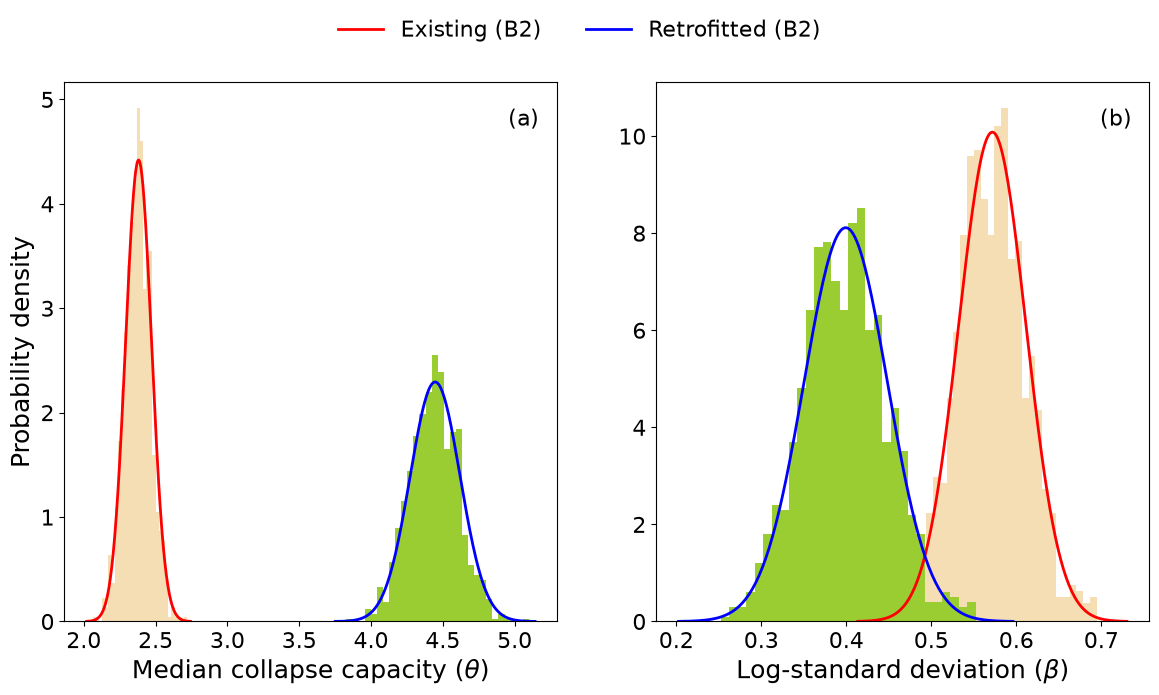

In [5]:
building_no = 3  # options are: 1, 3, 5, 7
mle_only = {"MLE": (r"Var[$\theta$]", r"Var[$\beta$]", "-")}
fig = parameter_figure(building_no, mle_only)

Same comparison with the sandwich (QMLE, dashed) overlaid on the MLE (solid) distributions:

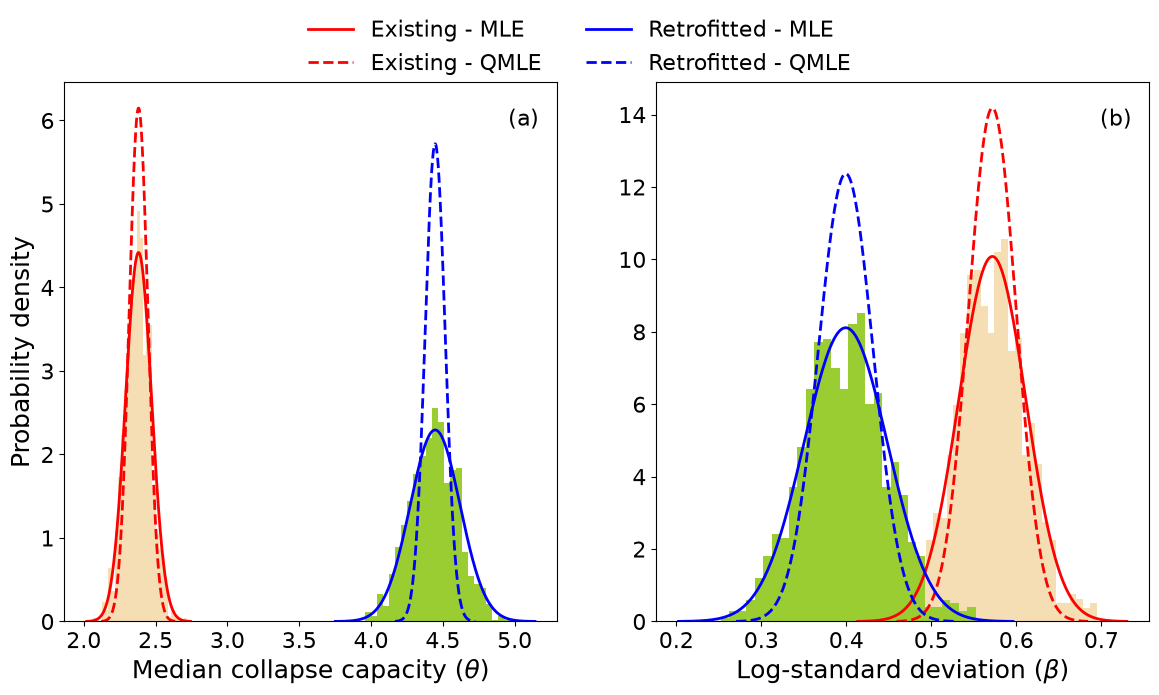

In [6]:
both = {
    "MLE": (r"Var[$\theta$]", r"Var[$\beta$]", "-"),
    "QMLE": (r"QVar[$\theta$]", r"QVar[$\beta$]", "--"),
}
fig = parameter_figure(building_no, both)
# fig.savefig(f"parameterDistributionCompiled_{building_no // 2 + 1}.png")

## A closer look at one building: B2-Existing

In [7]:
counts = df["B2-Existing"].to_numpy()
fit = pf.fit_msa(hazard_level, counts, num_gm)
fit.summary()  # median (theta) and log-standard deviation (beta), with MLE and sandwich standard errors

,estimate,se_mle,se_sandwich,ratio
theta,2.381143,0.090271,0.064879,0.718716
beta,0.571751,0.039566,0.028133,0.711049


The information-matrix equivalence test of the paper (Eq. 19): under correct specification `A + B = 0`, where
`A` is the Hessian of the log-likelihood and `B` the outer product of the scores.

In [8]:
cov = fit.covariance_estimates()
print("A (Hessian of the log-likelihood):\n", cov.hessian)
print("\nB (outer product of the scores):\n", cov.outer_product)
print("\nA + B (zero if correctly specified):\n", cov.equality_gap)

A (Hessian of the log-likelihood):
 [[-122.76360368    5.49652752]
 [   5.49652752 -639.02994304]]

B (outer product of the scores):
 [[ 63.60955594 -14.19259803]
 [-14.19259803 324.10648998]]

A + B (zero if correctly specified):
 [[ -59.15404774   -8.69607052]
 [  -8.69607052 -314.92345306]]


Variance-covariance matrix from the inverse Fisher information (MLE):

In [9]:
cov.mle_cov

array([[8.14887499e-03, 7.00914192e-05],
       [7.00914192e-05, 1.56547478e-03]])

Variance-covariance matrix from the Huber-White sandwich estimator (QMLE), `A⁻¹ B A⁻¹`.

> **Note.** Version 0.0.x formed this as the *elementwise* product `A⁻¹ * B * A⁻¹`, which is how the paper's
> Appendix B and figures were produced. The default is now the matrix product; the diagonals (all the variances
> reported in the paper) differ by less than 1%. Pass `legacy_elementwise_sandwich=True` to reproduce the
> published numbers exactly.

In [10]:
cov.sandwich_cov

array([[ 0.00420932, -0.00010923],
       [-0.00010923,  0.00079149]])

In [11]:
legacy = covariance_estimates(
    pf.CollapseData(hazard_level, counts, num_gm),
    pf.LognormalFragility(*fit.params),
    legacy_elementwise_sandwich=True,
)
legacy.sandwich_cov  # paper, Appendix B: [[4.2240e-3, -6.9977e-8], [-6.9977e-8, 7.9438e-4]]

array([[ 4.22393936e-03, -6.97254955e-08],
       [-6.97254955e-08,  7.94291433e-04]])

## Fragility curve with a confidence band

In [12]:
glm = pf.fit_msa(hazard_level, counts, num_gm, parametrization="glm")
# probit-GLM parameters and their covariance (R's glm convention: expected information)
print(glm.summary())
print(glm.covariance("expected"))
# transformed to the median and log-standard deviation
print(glm.lognormal_parameters("expected"))

           estimate    se_mle  se_sandwich     ratio
intercept -1.517411  0.123085     0.090950  0.738919
ln(im)     1.749015  0.121035     0.086062  0.711049
[[ 0.0150314  -0.01238487]
 [-0.01238487  0.01443799]]
LognormalSummary(theta=2.3811433728065823, beta=0.5717505323130798, cov=array([[8.17206141e-03, 6.28635985e-05],
       [6.28635985e-05, 1.54288316e-03]]))


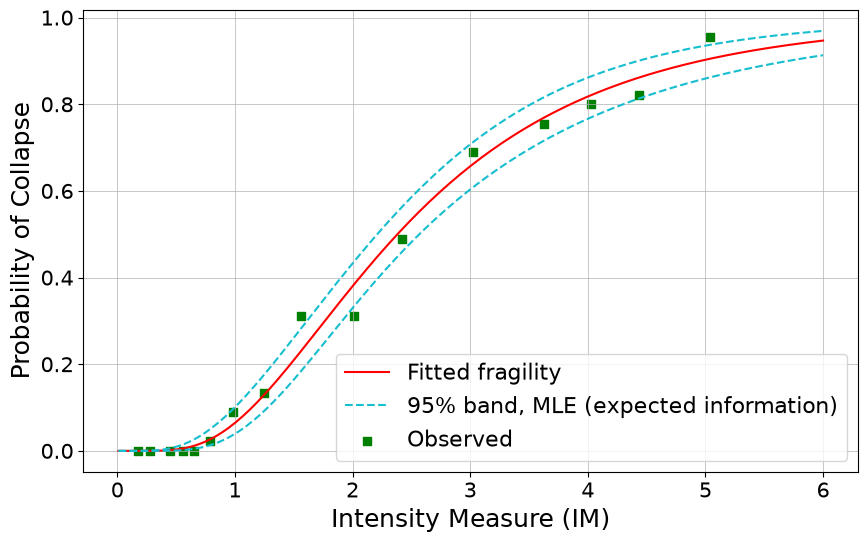

In [13]:
ax = pf.plot_fit(glm, im_grid=np.linspace(0.01, 6, 205), band="expected")
ax.set_xlabel("Intensity Measure (IM)", fontsize=18)
ax.set_ylabel("Probability of Collapse", fontsize=18)
ax.legend(fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=15)
# ax.figure.savefig("ConfidenceInterval.png")

## Collapse risk: MLE vs. sandwich uncertainty on the MAFC

In [14]:
mafc = pf.mean_annual_frequency(fit, hazard)
print(f"MAFC                      = {mafc:.3e}")
print(f"50-year collapse prob.    = {float(pf.probability_in_period(mafc, 50)):.4f}")
for label, cov in [("MLE", "expected"), ("QMLE/sandwich", "sandwich")]:
    std = pf.frequency_uncertainty(glm, hazard, cov=cov, method="paper").std
    print(f"std[MAFC] ({label:13s}) = {std:.3e}")

MAFC                      = 9.175e-04
50-year collapse prob.    = 0.0448
std[MAFC] (MLE          ) = 1.659e-04
std[MAFC] (QMLE/sandwich) = 1.225e-04
